# HAST Stationscluster: K-Means

**Zweck:** Gruppiert die HAST anhand der Feature-Tabelle aus [`00_eda_hast_stationsprofile.ipynb`](00_eda_hast_stationsprofile.ipynb) (`data/processed/hast_features.csv`) mit K-Means in Betriebsprofile.

**Eigenständig:** braucht nur diese eine CSV-Datei und Standard-Bibliotheken (pandas, numpy, matplotlib, scikit-learn) — keine Abhängigkeit zu `src/*.py`.

**Voraussetzung:** Das EDA-Notebook muss vorher einmal gelaufen sein, damit `data/processed/hast_features.csv` existiert.

## 1 · Setup & Daten laden

In [8]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

pd.set_option("display.max_columns", 40)
plt.rcParams["figure.facecolor"] = "white"

ROOT = Path.cwd().resolve()
while not (ROOT / "data" / "processed").is_dir() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
FEATURES_PATH = ROOT / "data" / "processed" / "hast_features.csv"
if not FEATURES_PATH.is_file():
    raise FileNotFoundError(
        f"{FEATURES_PATH} nicht gefunden - zuerst 00_eda_hast_stationsprofile.ipynb laufen lassen"
    )
features = pd.read_csv(FEATURES_PATH)
print(f"{len(features)} HAST-Profile geladen")
features.head()

101 HAST-Profile geladen


,rt_mean_winter,rt_p95,dt_mean_loaded,dt_std_loaded,rt_above_50_share_loaded,summer_flow_share,summer_flow_baseline,flow_ceiling_slope_per_month,peak_load_share,p95_load_share,flow_short_cycle_power,idle_share,energy_kwh_year,full_load_hours,Zählernummer,address,anschlusswert_kw,coverage,n_rows,n_hours
0,63.068956,75.9,17.084723,4.837782,0.999885,0.248129,0.0,32.892912,NaN,NaN,0.127965,0.627069,1948478.0,6026.133643,41566330,NaN,NaN,0.732206,23681,32342
1,63.427403,78.6,NaN,NaN,1.000000,0.249361,0.0,51.297490,NaN,NaN,0.128082,0.634686,1931280.0,5473.032714,41566331,NaN,NaN,0.732206,23681,32342
2,63.092601,74.6,NaN,NaN,0.999768,0.243702,0.0,47.918037,NaN,NaN,0.134345,0.618143,2021822.0,5680.823146,41566332,NaN,NaN,0.732144,23679,32342
3,34.293990,53.3,13.347791,3.859154,0.995984,0.000000,0.0,43.687088,NaN,NaN,0.198795,0.989145,91450.0,133.973044,41628863,NaN,NaN,0.732051,23676,32342
4,41.397956,59.2,NaN,NaN,NaN,0.000000,0.0,0.000000,NaN,NaN,NaN,1.000000,0.0,0.000000,41704231,NaN,NaN,0.732391,23687,32342


**Was macht der Code?**
- Sucht die Projektwurzel selbst: startet im aktuellen Ordner und geht nach oben, bis data/processed gefunden ist → Notebook läuft aus notebooks/ genauso wie aus dem Repo-Root
- ROOT != ROOT.parent verhindert eine Endlosschleife, falls der Ordner gar nicht existiert
- Bricht mit klarer Ansage ab, wenn hast_features.csv fehlt → sagt direkt, dass zuerst 00_eda_hast_stationsprofile.ipynb laufen muss
- Lädt die Tabelle: 101 HAST × 20 Spalten (14 Kennzahlen + Zählernummer/Adresse/Anschlusswert + coverage/n_rows/n_hours)
- Ab hier ist jede HAST eine Zeile — genau das Format, das K-Means braucht


## 2 · Feature-Auswahl & Vorverarbeitung

Kuratierte Teilmenge der Features: fehlende Werte medianimputiert, 1./99. Perzentil geclippt, standardisiert.

In [9]:
CLUSTER_FEATURES = [
    "rt_mean_winter", "dt_mean_loaded", "dt_std_loaded",
    "summer_flow_baseline", "flow_ceiling_slope_per_month",
    "peak_load_share", "p95_load_share", "flow_short_cycle_power",
    "idle_share", "full_load_hours",
]

X_raw = features[CLUSTER_FEATURES].replace([np.inf, -np.inf], np.nan)
missing_share = (X_raw.isna().mean() * 100).sort_values(ascending=False)
print("Anteil fehlender Werte je Cluster-Feature:")
display(missing_share.round(1).to_frame("% fehlend"))

imputer = SimpleImputer(strategy="median")
X_imputed = pd.DataFrame(imputer.fit_transform(X_raw), columns=CLUSTER_FEATURES)

bounds = X_imputed.quantile([0.01, 0.99])
X_clipped = X_imputed.clip(lower=bounds.loc[0.01], upper=bounds.loc[0.99], axis=1)

scaler = StandardScaler()
X = scaler.fit_transform(X_clipped)
print(f"Cluster-Matrix: {X.shape[0]} HAST × {X.shape[1]} Features")

Anteil fehlender Werte je Cluster-Feature:


,% fehlend
p95_load_share,15.8
peak_load_share,15.8
dt_std_loaded,5.9
dt_mean_loaded,5.9
flow_short_cycle_power,2.0
rt_mean_winter,0.0
flow_ceiling_slope_per_month,0.0
summer_flow_baseline,0.0
idle_share,0.0
full_load_hours,0.0


Cluster-Matrix: 101 HAST × 10 Features


**Was macht der Code?**
- Wählt **10 von 14** Kennzahlen aus — bewusst ohne rt_p95/rt_above_50_share_loaded (Dopplung zu rt_mean_winter), ohne summer_flow_share (Zwilling von summer_flow_baseline) und ohne energy_kwh_year (Größenmaß → würde „groß vs. klein" clustern statt „gesund vs. auffällig")
- inf → NaN: Schutz für die Divisions-Features; ein inf würde beim Standardisieren die ganze Spalte zerstören
- Zeigt **vor** der Imputation den Anteil fehlender Werte — danach ist nicht mehr erkennbar, was gemessen und was aufgefüllt ist: peak_load_share/p95_load_share 15,8 % (16 HAST ohne Anschlusswert in Nodes), dt_mean/std_loaded 5,9 % (nie über 0,5 kW gelaufen), flow_short_cycle_power 2,0 % → insgesamt 16 von 101 Zeilen betroffen
- **Median-Imputation:** K-Means kann NaN nicht verarbeiten und würde abbrechen. Median statt Mittelwert, weil ausreißerrobust. Nebenwirkung: imputierte Stationen werden zur Mitte gezogen
- **Clipping am 1./99. Perzentil:** betrifft nur 1–2 Werte je Feature, kappt aber die Extreme drastisch (summer_flow_baseline 16 640 → 7 820, Steigung −1 024 → −42). Nötig, weil K-Means quadrierte Abstände minimiert → ein Ausreißer zieht sonst ein ganzes Zentrum zu sich
- **Standardisierung:** Pflicht, weil die Einheiten um Größenordnungen auseinanderliegen (Std: Durchfluss ≈ 1 833 l/h vs. idle_share ≈ 0,22). Ohne z-Transformation bestimmen Durchfluss und Volllaststunden fast allein den Abstand → jetzt hat jedes Feature eine gleich starke Stimme
- Ergebnis: X = NumPy-Array **101 × 10** ohne Spaltennamen (deshalb später wieder CLUSTER_FEATURES zum Beschriften)
- **Zu diskutieren:** rt_mean_winter ↔ dt_mean_loaded korrelieren mit r = −0,79 → dieses Thema zählt im Abstandsmaß doppelt

## 3 · Anzahl Cluster wählen (Elbow & Silhouette)

,k,inertia,silhouette
0,2,820.264,0.217
1,3,683.615,0.215
2,4,604.766,0.206
3,5,541.387,0.153
4,6,495.702,0.171
5,7,450.527,0.167
6,8,409.233,0.181


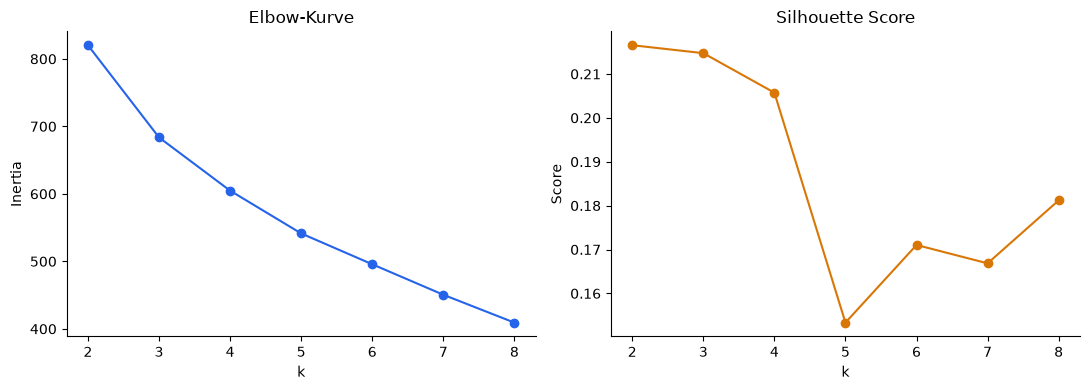

In [10]:
k_values = range(2, 9)
rows = []
for k in k_values:
    model = KMeans(n_clusters=k, n_init=20, random_state=42).fit(X)
    rows.append({
        "k": k,
        "inertia": model.inertia_,
        "silhouette": silhouette_score(X, model.labels_),
    })
k_metrics = pd.DataFrame(rows)
display(k_metrics.round(3))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(k_metrics["k"], k_metrics["inertia"], marker="o", color="#2563EB")
axes[0].set(title="Elbow-Kurve", xlabel="k", ylabel="Inertia")
axes[1].plot(k_metrics["k"], k_metrics["silhouette"], marker="o", color="#D97706")
axes[1].set(title="Silhouette Score", xlabel="k", ylabel="Score")
for ax in axes:
    ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
plt.show()

**Zusammenfassung**
- K-Means kann k nicht selbst bestimmen → diese Zelle testet k = 2…8 und bewertet jedes mit zwei Kennzahlen
- Kein k = 1 (Silhouette dort undefiniert), Schluss bei 8 (bei 101 HAST sonst nur noch Splitter)
- n_init=20: K-Means startet zufällig und landet in einem **lokalen** Optimum → 20 Durchläufe, der beste zählt. random_state=42 macht es reproduzierbar
- **Inertia** = Summe der quadrierten Abstände zum eigenen Zentrum. Sinkt zwangsläufig mit steigendem k → nicht das Minimum suchen, sondern den Knick
- **Silhouette** = pro Station (b − a) / max(a, b) mit a = Abstand zum eigenen Cluster, b = zum nächstbesten. −1 bis +1, hat ein echtes Maximum → dient in Zelle 4 als automatisches Kriterium
- Einordnung: > 0,5 stark · 0,25–0,5 schwach · < 0,25 keine echte Struktur

**Ergebnis bei unseren Daten**
- **Kein Ellbogen** — Inertia fällt gleichmäßig um 8–17 % je Schritt, kein Knick
- **Silhouette bei allen k < 0,22**, Maximum 0,217 bei k = 2, dicht gefolgt von 0,215 bei k = 3
- → Die HAST bilden **keine klar getrennten Typen**, sondern ein Kontinuum. Die Cluster sind eine nützliche Einteilung zum Priorisieren, keine natürlichen Gruppen — so muss es in der Auswertung auch formuliert werden
- Ab k = 3 existiert konstant ein **3er-Cluster** (bleibt bis k = 8 stabil) → sehr wahrscheinlich echte Ausreißer, siehe Zelle 6



## 4 · K-Means fitten

`K` wird automatisch über den besten Silhouette Score gewählt — bei Bedarf hier einfach überschreiben.

In [11]:
K = int(k_metrics.loc[k_metrics["silhouette"].idxmax(), "k"])
print(f"Gewähltes k (bester Silhouette Score): {K}")

kmeans = KMeans(n_clusters=K, n_init=50, random_state=42).fit(X)
features["cluster"] = kmeans.labels_
features["cluster"].value_counts().sort_index()

Gewähltes k (bester Silhouette Score): 2


cluster
0    38
1    63
Name: count, dtype: int64

**Zusammenfassung**
- idxmax() liefert die **Zeilennummer** des besten Silhouette Scores, nicht das k selbst — .loc[zeile, "k"] holt daraus den echten k-Wert. Wichtig, weil der Index bei 0 startet und k bei 2 (Versatz von 2)
- n_init=50 statt 20 wie in Zelle 3: Hier läuft **ein** finales Modell, dessen Ergebnis alles Weitere trägt → mehr Neustarts als billige Absicherung gegen ein schlechtes lokales Optimum
- features["cluster"] = kmeans.labels_ ordnet die Labels **allein über die Zeilenreihenfolge** zu. Funktioniert nur, weil in Zelle 2 nichts gefiltert wurde (Imputation füllt auf, löscht nichts) → **ein** .dropna() **dort würde die Labels lautlos falschen Stationen zuweisen**
- sort_index() sortiert die Ausgabe nach Clusternummer statt nach Häufigkeit → stabile Reihenfolge
- Clusternummern sind reine Etiketten, keine Rangfolge — 0 ist nicht „besser" als 1

**Ergebnis: K = 2, Größen 63 / 38**

- Cluster 0 (38 HAST): Rücklauf 56,4 °C, Spreizung 15,9 K, Sommer-Durchfluss 40,5 l/h → **die auffällige Gruppe**
- Cluster 1 (63 HAST): Rücklauf 41,6 °C, Spreizung 28,5 K, Sommer-Durchfluss 0 → sauberer Betrieb
- Getrennt wird also im Wesentlichen entlang der **Rücklauf-/Spreizungs-Achse** — fernwärmetechnisch genau die richtige Frage
- Geprüft: kein Imputations-Artefakt (aufgefüllte Stationen liegen in beiden Clustern, 24 % vs. 11 %) und stabil gegen den Seed (random_state=7 liefert identische Aufteilung)
- **Offene Entscheidung:** k = 2 gewinnt nur knapp gegen k = 3 (0,217 vs. 0,215). k = 4 würde den stabilen 3er-Ausreißercluster sichtbar machen → Wahl im Text begründen, nicht der Automatik überlassen (K = 4 direkt nach Zeile 1 setzen)

## 5 · Cluster visualisieren (PCA)

Erklärte Varianz: PC1 27.0%, PC2 16.4% — zusammen 43.4%


,PC1,PC2
rt_mean_winter,0.48,0.36
summer_flow_baseline,0.39,-0.17
dt_mean_loaded,-0.37,-0.37
idle_share,-0.33,0.04
flow_short_cycle_power,-0.33,-0.24
flow_ceiling_slope_per_month,0.32,-0.34
full_load_hours,0.32,-0.22
dt_std_loaded,-0.17,0.17
peak_load_share,-0.13,0.55
p95_load_share,-0.09,0.37


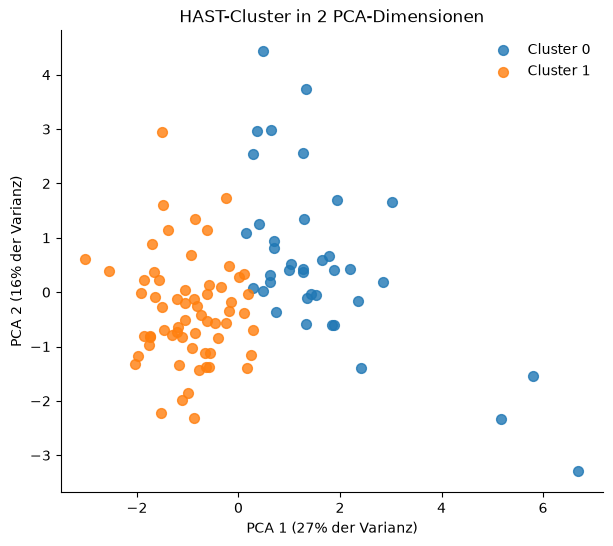

In [12]:
pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(X)
ev = pca.explained_variance_ratio_
print(f"Erklärte Varianz: PC1 {ev[0]:.1%}, PC2 {ev[1]:.1%} — zusammen {ev.sum():.1%}")

# Ladungen: woraus sind die beiden Achsen gemischt? Nach dem Betrag der
# PC1-Ladung sortiert, damit oben steht, was die Hauptachse treibt.
loadings = pd.DataFrame(pca.components_.T, index=CLUSTER_FEATURES, columns=["PC1", "PC2"])
display(loadings.reindex(loadings["PC1"].abs().sort_values(ascending=False).index).round(2))

fig, ax = plt.subplots(figsize=(7, 6))
palette = plt.cm.tab10.colors
for cluster in sorted(features["cluster"].unique()):
    mask = features["cluster"] == cluster
    ax.scatter(coords[mask, 0], coords[mask, 1], s=50, alpha=0.8,
               color=palette[cluster % len(palette)], label=f"Cluster {cluster}")
ax.set(title="HAST-Cluster in 2 PCA-Dimensionen",
       xlabel=f"PCA 1 ({ev[0]:.0%} der Varianz)",
       ylabel=f"PCA 2 ({ev[1]:.0%} der Varianz)")
ax.legend(frameon=False)
ax.spines[["top", "right"]].set_visible(False)
plt.show()

**Was macht der Code?**
- X hat 10 Dimensionen, ein Diagramm kann 2 zeigen → PCA dreht die Punktwolke so, dass die **Richtung größter Streuung** zur x-Achse wird (PC1), die zweitgrößte im rechten Winkel dazu zur y-Achse (PC2)
- Beide Achsen sind **Mischungen aller 10 Features**, keine Auswahl von zweien
- Läuft auf dem standardisierten X — ohne die z-Transformation aus Zelle 2 wäre PC1 einfach die Richtung von summer_flow_baseline (Std 1 833)
- pca wird als Variable gehalten (nicht als Einzeiler), damit explained_variance_ratio_ und components_ danach noch verfügbar sind
- **Ladungstabelle:** pca.components_ ist 2 × 10, .T dreht es auf 10 × 2 (eine Zeile je Feature). Sortiert nach dem **Betrag** der PC1-Ladung, weil −0,37 genauso einflussreich ist wie +0,37
- Ein scatter-Aufruf **je Cluster** (statt einem für alle), damit jede Gruppe einen Legendeneintrag bekommt; palette[cluster % 10] lässt die Farben umlaufen → kein IndexError, falls man mit größerem k experimentiert

**Wie man das Bild liest**
- Achsen haben **keine Einheit**, das Vorzeichen ist beliebig → links/rechts bedeutet nichts, nur **Abstände und Nachbarschaften** zählen
- Das Bild ist ein Schatten der 10D-Struktur: geclustert wurde in 10 Dimensionen, gezeigt werden 2. Überlappung im Bild heißt nicht Überlappung in Wirklichkeit → Plausibilitätsprüfung, kein Beweis
- PC1 erklärt **27,0 %**, PC2 **16,4 %**, zusammen **43,4 %** → gut 56 % der Streuung sind nicht im Bild. Steht jetzt direkt in den Achsenbeschriftungen, damit die Grafik ihren Vorbehalt selbst mitträgt

**Bedeutung der Achsen (aus den Ladungen)**
- **PC1 = Rücklauf/Spreizung:** rechts hoher rt_mean_winter (+0,48) und Sommer-Durchfluss (+0,39), links große Spreizung dt_mean_loaded (−0,37), flow_short_cycle_power (−0,33) und idle_share (−0,33)
- → das ist **dieselbe Achse, nach der K-Means trennt** (Cluster 0 bei PC1 ≈ +1,6, Cluster 1 ≈ −1,0) — deshalb ist die Trennung im Bild überhaupt sichtbar
- **PC2 = Auslastungsgrad:** peak_load_share (+0,55), p95_load_share (+0,37) → steht quer zur Clustertrennung, beschreibt unabhängig davon, wie stark eine Station relativ zu ihrem Anschlusswert gefahren wird


## 6 · Cluster-Profile

In [13]:
profile = features.groupby("cluster")[CLUSTER_FEATURES].median()
sizes = features["cluster"].value_counts().sort_index().rename("n_hast")
display(profile.round(3).join(sizes))

,rt_mean_winter,dt_mean_loaded,dt_std_loaded,summer_flow_baseline,flow_ceiling_slope_per_month,peak_load_share,p95_load_share,flow_short_cycle_power,idle_share,full_load_hours,n_hast
cluster,,,,,,,,,,,
0,56.427,15.922,7.462,40.5,-0.463,1.554,0.633,0.129,0.303,3088.296,38
1,41.587,28.445,8.004,0.0,0.168,1.701,0.668,0.205,0.427,2138.698,63


**Was macht der Code?**
- groupby("cluster")[CLUSTER_FEATURES].median() → eine Zeile je Cluster, eine Spalte je Kennzahl
- **Entscheidend:** läuft auf features, nicht auf X → Werte in **echten Einheiten** (°C, K, l/h, h) statt in Standardabweichungen. K-Means bildet die Gruppen im abstrakten Raum, diese Zelle übersetzt sie zurück in Fernwärme-Sprache — hier bekommen die Cluster ihre Bedeutung
- **Median statt Mittelwert**, konsequent zum Clipping aus Zelle 2: ein Extremwert soll das Gruppenprofil nicht verziehen
- features enthält hier noch die **echten** NaN (die Imputation lief auf einer Kopie und wurde nie zurückgeschrieben) → median() überspringt sie, das Profil zeigt **tatsächlich gemessene** Werte → Gegenprobe: auf den imputierten Daten wäre peak_load_share in beiden Clustern 1,678, der Unterschied (1,554 vs. 1,701) also **verschwunden** → Preis: unterschiedliche Fallzahlen je Zeile (bei peak_load_share 29 von 38 bzw. 56 von 63) — einmal in der Arbeit erwähnen
- .rename("n_hast") ist Pflicht, nicht Kosmetik: join() lehnt eine namenlose Series mit ValueError ab
- .join(sizes) verbindet über den **Index** (Clusternummer), nicht über die Position → nichts kann verrutschen

**Ergebnis (k=2, Flottenmedian als Referenz)**
- **Cluster 0 — auffällig (38 HAST):** Rücklauf 56,4 °C (Flotte 44,9), Spreizung nur 15,9 K (Flotte 26,0), **40,5 l/h Sommer-Durchfluss** (Flotte 0), 3 088 Volllaststunden, niedrigster idle_share (0,30) → Bild einer Station, die durchgehend umwälzt, ohne Wärme abzugeben: Verdacht auf Zirkulationsverluste, hydraulischen Kurzschluss oder nicht schließendes Ventil. Netzseitig teuer, weil hoher Rücklauf die Vorlauftemperatur der ganzen Leitung hochzieht
- **Cluster 1 — Normalbetrieb (63 HAST):** Spreizung 28,4 K, Sommer-Durchfluss 0, höherer Leerlaufanteil (0,43) → öffnet bei Bedarf, sonst zu
- Der höhere flow_short_cycle_power in Cluster 1 (0,21 vs. 0,13) ist **kein Widerspruch**, sondern Folge: Wer taktet, hat kurze Zyklen; wer durchläuft, hat keine

## 7 · Ergebnis speichern

In [14]:
out_path = ROOT / "data" / "processed" / "hast_clusters.csv"
export_cols = ["Zählernummer", "address", "cluster", "coverage"] + CLUSTER_FEATURES
features[export_cols].to_csv(out_path, index=False)

# Lauf-Kontext danebenlegen: ohne k, Gütemaß und Seed lässt sich später nicht
# mehr rekonstruieren, unter welchen Annahmen die Zuordnung entstanden ist.
meta_path = out_path.with_suffix(".json")
meta = {
    "erzeugt": pd.Timestamp.now().isoformat(timespec="seconds"),
    "quelle": str(FEATURES_PATH.relative_to(ROOT)),
    "n_hast": int(len(features)),
    "k": int(K),
    "silhouette": round(float(k_metrics.loc[k_metrics["k"] == K, "silhouette"].iloc[0]), 4),
    "random_state": 42,
    "vorverarbeitung": "Median-Imputation -> Clipping 1./99. Perzentil -> StandardScaler",
    "cluster_features": CLUSTER_FEATURES,
    "clustergroessen": {int(c): int(n) for c, n in features["cluster"].value_counts().sort_index().items()},
    "coverage_min": round(float(features["coverage"].min()), 3),
}
meta_path.write_text(json.dumps(meta, indent=2, ensure_ascii=False), encoding="utf-8")

print(f"Cluster-Zuordnung -> {out_path}")
print(f"Lauf-Kontext      -> {meta_path}")

Cluster-Zuordnung gespeichert -> /Users/seb/Desktop/projektseminar-code/data/processed/hast_clusters.csv


**Was macht der Code?**
- Schreibt Zählernummer, Adresse, Cluster und die 10 Cluster-Features nach `data/processed/hast_clusters.csv`
- **`coverage` wandert mit in den Export** — sagt für jede Station, auf wie vielen echten Messstunden ihre Kennzahlen beruhen (Spannweite 16,7 % bis 98,7 %). Ohne diese Spalte kann eine nachgelagerte Auswertung nicht unterscheiden, ob ein auffälliger Wert belastbar ist oder auf sechs Monaten Daten beruht
- **Lauf-Kontext als JSON daneben:** gewähltes k, Silhouette Score, Seed, Vorverarbeitungskette, Clustergrößen und Feature-Liste
  → Ohne diese Datei ist in drei Wochen nicht mehr rekonstruierbar, unter welchen Annahmen die CSV entstanden ist — besonders relevant, weil `K` automatisch gewählt wird und sich bei neuen Daten ändern kann
- `with_suffix(".json")` leitet den Namen vom CSV-Pfad ab → die beiden Dateien bleiben zwangsläufig gepaart

**Achtung beim Weitergeben:** Die CSV enthält Zählernummern und Adressen. `data/processed/` ist gitignored und bleibt es — siehe Datenschutz-Abschnitt in [`docs/README.md`](../docs/README.md).

## Zusammenfassung & Bewertung

### Ergebnis

**k = 2, Aufteilung 63 / 38.** Getrennt wird entlang der Rücklauf-/Spreizungs-Achse:

| Kennzahl | Cluster 0 (38) | Cluster 1 (63) | Flotte |
|---|---|---|---|
| `rt_mean_winter` | **56,4 °C** | 41,6 °C | 44,9 |
| `dt_mean_loaded` | **15,9 K** | 28,4 K | 26,0 |
| `summer_flow_baseline` | **40,5 l/h** | 0,0 | 0,0 |
| `idle_share` | 0,30 | 0,43 | 0,39 |

Cluster 0 wälzt durchgehend Wasser um, ohne viel Wärme abzugeben — Verdacht auf
Zirkulationsverluste oder hydraulischen Kurzschluss. Fernwärmetechnisch genau die
richtige Achse.

**Aber der Silhouette Score bleibt bei allen k unter 0,22** (Schwelle für
„schwache Struktur": 0,25), die Elbow-Kurve hat keinen Knick. Die HAST zerfallen
nicht in Typen — die Trennung ist eine Grenze durch ein Kontinuum. Immerhin
stabil: Bootstrap-ARI 0,90, seed-unabhängig, kein Imputations-Artefakt.

**Belastbarster Einzelbefund:** Bei k = 3 finden K-Means, Ward und GMM unabhängig
voneinander denselben Dreier-Cluster — drei Stationen mit Winterrücklauf
59–62 °C, Sommerdurchfluss bis 16 640 l/h, `idle_share` nahe null.

### Die Cluster passen nicht zur Ground Truth

Join mit `data/processed/inspections_tidy.csv` über 55 Stationen:

| | Cluster 0 | Cluster 1 | Test |
|---|---|---|---|
| mind. eine Maßnahme | 75,0 % | 79,5 % | p = 0,73 |
| Ø Anzahl Maßnahmen | 1,62 | 1,33 | p = 0,85 |
| Filter gereinigt | 56,2 % | 41,0 % | p = 0,38 |

Kein Unterschied ist signifikant. Kontinuierlich gerechnet: Winterrücklauf gegen
Anzahl Maßnahmen ergibt **rho = −0,06, p = 0,69**.

Ursache ist dieselbe wie beim ML-Klassifikator (siehe
[`docs/ml-klassifikator.md`](../docs/ml-klassifikator.md)): **Basisrate 82 %.**
„Mindestens eine Maßnahme" ist bei fast jeder Station wahr. Ein fast konstantes
Label kann nichts trennen. Das Problem ist das Ziel, nicht die Methode.

### Zu beheben

1. **`full_load_hours` ist kein Jahreswert.** `energy_year` ist die Differenz über
   die *gesamte* Historie — die ist 0,88 bis 4,72 Jahre lang. Eine Station kommt
   auf 14 689 Volllaststunden; ein Jahr hat 8 760.
   Fix: `energy_year / (n_hours / 8760)` in `compute_hast_features()`.
   Blockiert alles andere.
2. **Adressschlüssel zentral normalisieren.** Naiver Join trifft 21 von 101, mit
   `_normalize_address()` aus [`src/load_data.py`](../src/load_data.py) sind es 55.
   Die Funktion gibt es längst.
3. **k fest setzen statt automatisch** (aktuell entscheidet 0,217 gegen 0,215),
   **`coverage` nutzen** (16,7 % bis 98,7 % Abdeckung, derzeit gleich gewichtet),
   **Kontext in Zelle 7 mitspeichern** (k, Score, Seed, coverage).

**Falle:** Ward erreicht bei k = 2 einen Silhouette Score von 0,544 — doppelt so
hoch wie K-Means. Wertlos: Die Aufteilung ist 98 zu 3, Ward isoliert nur die
Ausreißer. Nie ohne Clustergrößen zitieren.

### Wie es weitergehen kann

**A · Fragestellung wechseln — von Fehlererkennung zu Rücklaufoptimierung.**
Die Rücklauftemperatur ist gemessen, kontinuierlich, hat kein Label-Problem und
ist der direkte wirtschaftliche Hebel. Statt „welche Station ist defekt" (Label
unbrauchbar) → „welche kostet das Netz am meisten Rücklauf". PC1 trägt diese
Frage bereits.

**B · Die Zeitachse nutzen.** Größtes ungenutztes Kapital: bis zu 4,7 Jahre
Stundendaten, eingedampft auf eine statische Zahl pro Station. Ein Rücklauf, der
über zwei Jahre um 6 K steigt, ist ein härteres Signal als einer, der konstant
hoch liegt. Braucht keine Labels.

**C · Das Label reparieren.** Nur technisch eingreifende Maßnahmen (Stellventil,
Regler, Durchfluss) als positiv werten, Routine wie Filterreinigung als negativ —
dann sinkt die Basisrate in einen trennbaren Bereich. Fachliche Entscheidung für
ÜZ.

**D · Die drei Ausreißer als eigenes Ergebnis.** Erst in die Rohzeitreihen
schauen: echter Betriebszustand oder defekter Zähler? Für eine
Wartungsempfehlung mehr wert als jede Clusterzuordnung.
